# Day 08 Mini Project — Customer Segmentation using K-Means

## Kaggle Dataset

**Dataset:** Mall Customer Segmentation Data

**Kaggle:** https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

In this project we will use:
- Customer Age
- Annual Income
- Spending Score

to discover customer groups using **K-Means Clustering**.


## Project Problem Statement

An e-commerce company wants to understand its customers better.

The company does not have predefined customer categories.

We will use **K-Means Clustering** to automatically discover groups of similar customers and then interpret those groups for business use.


## Project Workflow

`Load → Inspect → Clean → Analyze → Select Features → Scale → Elbow Method → K-Means → Cluster → Visualize → Analyze → Business Insights`


## Step 1 — Install / Import Libraries

In Google Colab, run this cell first.


In [1]:
!pip -q install kagglehub


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


## Step 2 — Download the Dataset from Kaggle

This downloads the **actual Kaggle dataset** directly into the Colab environment.

If Kaggle asks for authentication in your environment, follow the Kaggle authentication prompt.


In [3]:
import kagglehub

path = kagglehub.dataset_download(
    "vjchoudhary7/customer-segmentation-tutorial-in-python"
)

print("Dataset downloaded to:", path)


Using Colab cache for faster access to the 'customer-segmentation-tutorial-in-python' dataset.
Dataset downloaded to: /kaggle/input/customer-segmentation-tutorial-in-python


## Step 3 — Find the CSV File

In [4]:
from pathlib import Path

files = list(Path(path).rglob("*.csv"))

print("CSV files found:")
for file in files:
    print(file)


CSV files found:
/kaggle/input/customer-segmentation-tutorial-in-python/Mall_Customers.csv


## Step 4 — Load the Kaggle CSV

In [5]:
csv_file = files[0]

df = pd.read_csv(csv_file)

print(df.head())


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


## Step 5 — Inspect the Dataset

In [6]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
print(df.head())


Shape: (200, 5)

Columns:
['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Data Types:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

First 5 Rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


## Step 6 — Check Missing Values

In [7]:
print(df.isnull().sum())


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


## Step 7 — Check Duplicate Rows

In [8]:
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


## Step 8 — Basic Statistics

In [9]:
print(df.describe())


       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


## Step 9 — Analyze the Dataset

In [10]:
print("Average Age:", df["Age"].mean())
print("Average Annual Income:", df["Annual Income (k$)"].mean())
print("Average Spending Score:", df["Spending Score (1-100)"].mean())


Average Age: 38.85
Average Annual Income: 60.56
Average Spending Score: 50.2


## Step 10 — Analyze Gender Distribution

In [12]:
print(df["Gender"].value_counts())


Gender
Female    112
Male       88
Name: count, dtype: int64


## Step 11 — Visualize Age Distribution

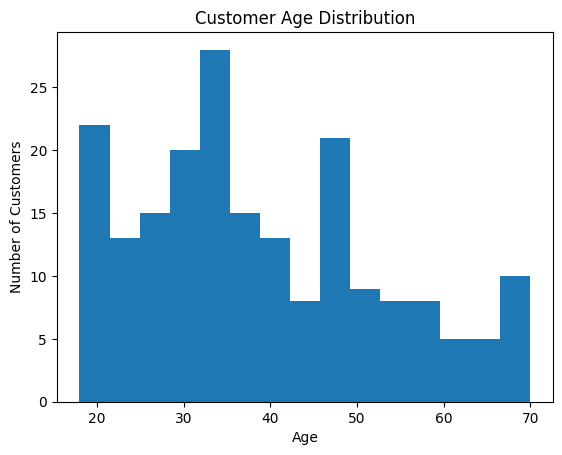

In [13]:
plt.hist(df["Age"], bins=15)

plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.title("Customer Age Distribution")

plt.show()


## Step 12 — Visualize Income Distribution

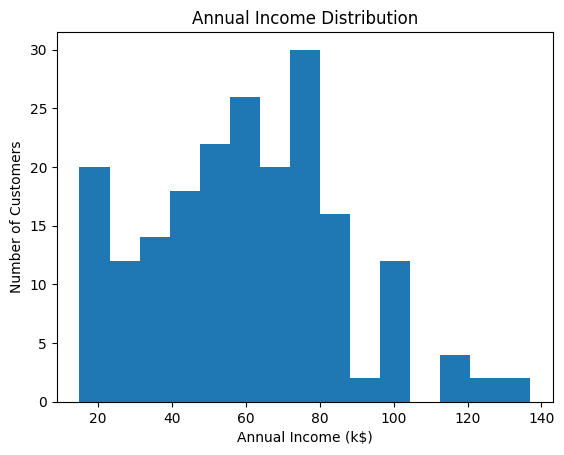

In [14]:
plt.hist(df["Annual Income (k$)"], bins=15)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")
plt.title("Annual Income Distribution")

plt.show()


## Step 13 — Visualize Spending Score Distribution

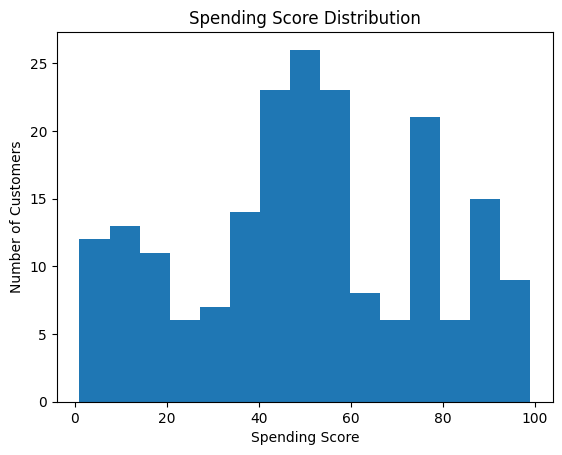

In [15]:
plt.hist(df["Spending Score (1-100)"], bins=15)

plt.xlabel("Spending Score")
plt.ylabel("Number of Customers")
plt.title("Spending Score Distribution")

plt.show()


## Step 14 — Analyze Income vs Spending

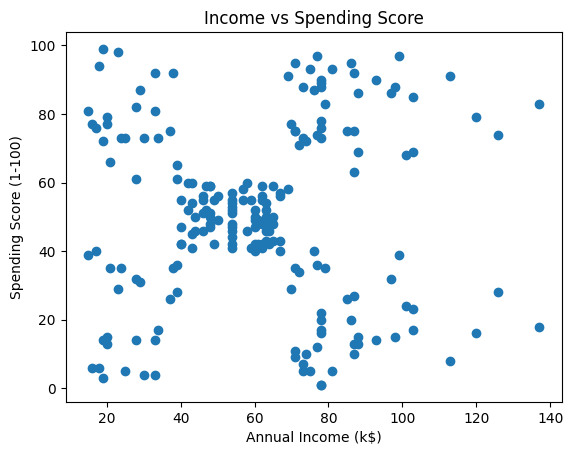

In [16]:
plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"]
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Income vs Spending Score")

plt.show()


## Step 15 — Select Features

For the main customer segmentation model we will use:

- Annual Income
- Spending Score

We do not use `CustomerID` because it is only an identifier.


In [17]:
X = df[
    [
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
]

print(X.head())


   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


## Step 16 — Feature Scaling

K-Means is distance-based, so scaling is important when feature ranges differ.

We will use `StandardScaler`.


In [18]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])


[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


## Step 17 — Elbow Method

In [19]:
inertia = []

for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

print(inertia)


[399.99999999999994, 269.69101219276405, 157.70400815035939, 108.92131661364358, 65.56840815571681, 55.057348270385965, 44.86475569922555, 37.22818767758587, 32.39226763033118, 29.981897788243703]


## Step 18 — Plot Elbow Curve

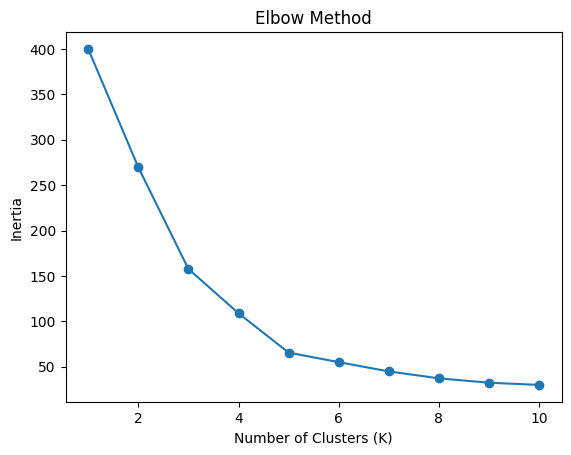

In [20]:
plt.plot(
    range(1, 11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()


## Step 19 — Choose K

For this dataset, inspect the elbow curve and choose a sensible value of K.

For the classroom project, we will continue with:

`K = 5`

The exact choice should be justified by the curve rather than blindly assumed.


In [21]:
K = 5

model = KMeans(
    n_clusters=K,
    random_state=42,
    n_init=10
)

model.fit(X_scaled)


KMeans(n_clusters=5, n_init=10, random_state=42)

## Step 20 — Get Cluster Labels

In [22]:
df["Cluster"] = model.labels_

print(df.head())


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


## Step 21 — Get Cluster Centers

In [23]:
centers_scaled = model.cluster_centers_

print(centers_scaled)


[[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]


## Step 22 — Convert Centers Back to Original Scale

In [24]:
centers_original = scaler.inverse_transform(
    centers_scaled
)

centers_df = pd.DataFrame(
    centers_original,
    columns=[
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
)

print(centers_df)


   Annual Income (k$)  Spending Score (1-100)
0           55.296296               49.518519
1           86.538462               82.128205
2           25.727273               79.363636
3           88.200000               17.114286
4           26.304348               20.913043


## Step 23 — Visualize Customer Clusters

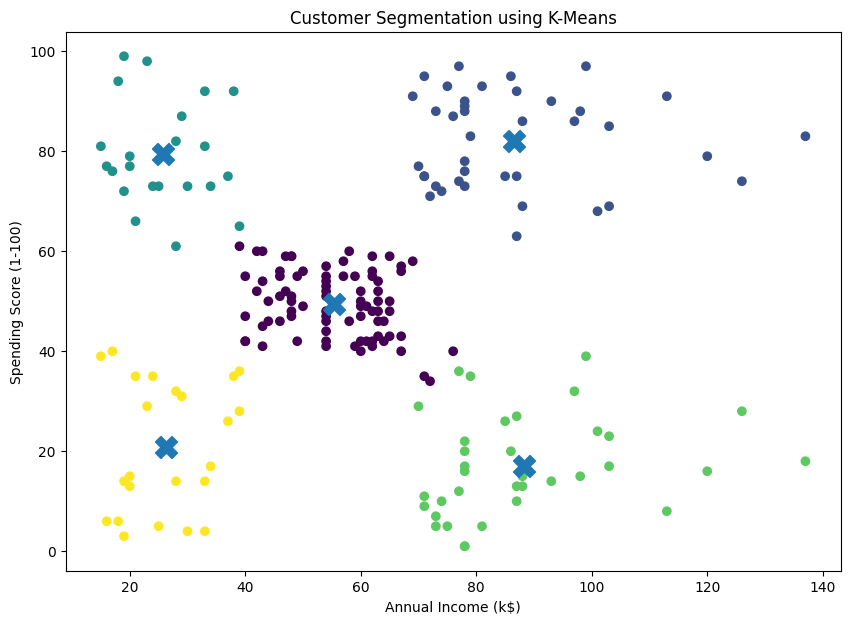

In [25]:
plt.figure(figsize=(10, 7))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"]
)

plt.scatter(
    centers_original[:, 0],
    centers_original[:, 1],
    marker="X",
    s=250
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation using K-Means")

plt.show()


## Step 24 — Cluster Summary

In [26]:
cluster_summary = df.groupby("Cluster")[
    [
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
].mean()

print(cluster_summary)


               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        42.716049           55.296296               49.518519
1        32.692308           86.538462               82.128205
2        25.272727           25.727273               79.363636
3        41.114286           88.200000               17.114286
4        45.217391           26.304348               20.913043


## Step 25 — Cluster Size

In [27]:
cluster_counts = df["Cluster"].value_counts().sort_index()

print(cluster_counts)


Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


## Step 26 — Give Business Meaning to Clusters

The K-Means algorithm only produces labels such as `0`, `1`, `2`, `3`, `4`.

We should inspect the cluster averages and then assign meaningful business names.

Possible interpretations:

- Low income + low spending → Budget Customers
- High income + high spending → Premium Customers
- High income + low spending → Potential Customers
- Low income + high spending → Targeted/High-Value Relative to Income
- Middle income + middle spending → Regular Customers

**Do not assign these names blindly. Use the actual cluster summary.**


## Step 27 — Create a Business Summary Table

In [28]:
business_summary = cluster_summary.copy()

business_summary["Customer Count"] = cluster_counts

print(business_summary)


               Age  Annual Income (k$)  Spending Score (1-100)  Customer Count
Cluster                                                                       
0        42.716049           55.296296               49.518519              81
1        32.692308           86.538462               82.128205              39
2        25.272727           25.727273               79.363636              22
3        41.114286           88.200000               17.114286              35
4        45.217391           26.304348               20.913043              23


## Step 28 — Optional: Analyze Age

We can also inspect whether different clusters have different age profiles.


In [29]:
age_summary = df.groupby("Cluster")["Age"].mean()

print(age_summary)


Cluster
0    42.716049
1    32.692308
2    25.272727
3    41.114286
4    45.217391
Name: Age, dtype: float64


## Step 29 — Optional: Try Different K Values

Compare different cluster counts.



In [30]:
for k in [2, 3, 4, 5, 6]:
    model_test = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model_test.fit(X_scaled)

    print(
        "K =", k,
        "| Inertia =", model_test.inertia_
    )


K = 2 | Inertia = 269.69101219276405
K = 3 | Inertia = 157.70400815035939
K = 4 | Inertia = 108.92131661364358
K = 5 | Inertia = 65.56840815571681
K = 6 | Inertia = 55.057348270385965


## Step 30 — Final Business Insights

Answer these questions from your cluster summary:

1. Which cluster has the highest average income?
2. Which cluster has the highest average spending score?
3. Which cluster has the lowest spending score?
4. Which cluster could be targeted for premium products?
5. Which cluster could receive discount campaigns?
6. Which cluster could be targeted to increase spending?


# 🎯 Final Project Output

Your final project should contain:

### 1. Dataset
Kaggle Mall Customer Segmentation Data

### 2. Data Analysis
- Shape
- Columns
- Missing values
- Duplicates
- Descriptive statistics

### 3. Visualization
- Age distribution
- Income distribution
- Spending distribution
- Income vs Spending

### 4. Machine Learning
- Feature scaling
- Elbow Method
- K-Means
- Cluster labels
- Centroids

### 5. Business Analysis
- Cluster summary
- Customer groups
- Marketing recommendations


# 🧪 Day 8 Challenge

Create a function:

`predict_customer_segment(income, spending_score)`

The function should:

1. Accept income and spending score.
2. Scale the input using the same scaler.
3. Predict the customer's cluster.
4. Return the cluster number.

Example:

`predict_customer_segment(80, 90)`


In [31]:
def predict_customer_segment(income, spending_score):
    customer = pd.DataFrame({
        "Annual Income (k$)": [income],
        "Spending Score (1-100)": [spending_score]
    })

    customer_scaled = scaler.transform(customer)

    cluster = model.predict(customer_scaled)

    return cluster[0]


print(
    "Predicted Cluster:",
    predict_customer_segment(80, 90)
)


Predicted Cluster: 1
